# Phase 2: Multi-Class Classification Pipeline — KNN & Ensemble

This notebook implements the complete 10-class classification pipeline for the MNIST dataset.

**Required Improvements included:**
1. **Feature Engineering**: Using PCA (95% variance).
2. **Hyperparameter Tuning with Cross-Validation**: Implementing 3-Fold CV from scratch to find the best K.
3. **Learning Curves**: Plotting train vs validation accuracy to diagnose bias/variance tradeoff.
4. **Ensemble Methods**: Implementing a custom **Bagged KNN** ensemble classifier.
5. **Data Balancing**: Under-sampling all 10 classes to balance the dataset.


## 1) Environment Setup and Imports

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, repo_root)

from src.utils.mnist_features import  load_mnist, split_data, balance_multi_classes, normalize_data, build_features, class_distribution, run_simple_cv
from src.utils.evaluation import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, per_class_accuracy
from src.utils.bias_variance_analysis import learning_curve, summarize_bias_variance, complexity_curve
from src.utils.model_diagnostics import build_learning_curve, plot_learning_curve, print_diagnosis
from src.models.Naive_Bayes import NaiveBayes

In [2]:
# Explicit experiment config
RANDOM_STATE = 42
DATA_PATH = "../../data/mnist.npz"

TEST_SIZE = 0.20
VAL_SIZE = 0.0

# Optional class-imbalance handling (applied on train split only).
APPLY_CLASS_BALANCING = True
BALANCE_METHOD = "undersample"

FEATURES = ["flatten", "hog", "pca"]
K_VALUES = [1, 3, 5, 7, 9]
CV_FOLDS = 5

print("RANDOM_STATE:", RANDOM_STATE)
print("FEATURES:", FEATURES)
print("K_VALUES:", K_VALUES)
print("CV_FOLDS:", CV_FOLDS)
print("DATA_PATH:", DATA_PATH)
print("APPLY_CLASS_BALANCING:", APPLY_CLASS_BALANCING)
print("BALANCE_METHOD:", BALANCE_METHOD)

RANDOM_STATE: 42
FEATURES: ['flatten', 'hog', 'pca']
K_VALUES: [1, 3, 5, 7, 9]
CV_FOLDS: 5
DATA_PATH: ../../data/mnist.npz
APPLY_CLASS_BALANCING: True
BALANCE_METHOD: undersample


## 2) Load and Inspect MNIST Dataset

Full dataset shape: (70000, 28, 28), Labels shape: (70000,)
Class distribution: {0: 6903, 1: 7877, 2: 6990, 3: 7141, 4: 6824, 5: 6313, 6: 6876, 7: 7293, 8: 6825, 9: 6958}


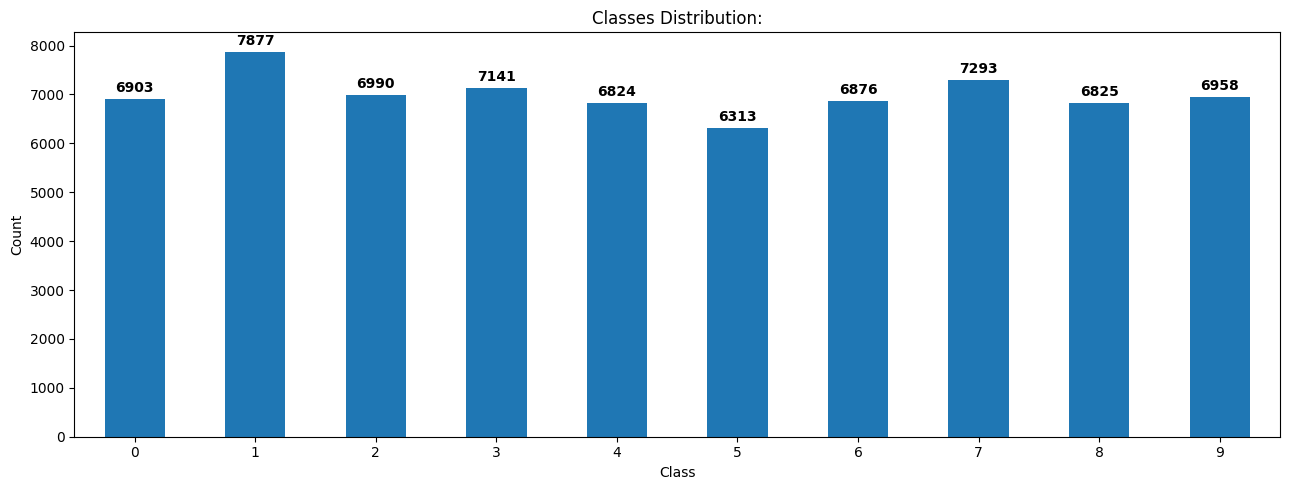

In [3]:
# Load the full MNIST dataset
x_all, y_all = load_mnist(DATA_PATH)
print(f'Full dataset shape: {x_all.shape}, Labels shape: {y_all.shape}')
print('Class distribution:', class_distribution(y_all))

label_counts = pd.Series(y_all).value_counts().reindex([0,1,2,3,4,5,6,7,8,9], fill_value=0)

plt.figure(figsize=(13, 5))
ax = label_counts.plot(kind='bar', rot=0)
for bar in ax.patches:
    height = bar.get_height()
    ax.text( bar.get_x() + bar.get_width() / 2, height + max(label_counts) * 0.01, f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold' )
plt.title(f'Classes Distribution:')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3) Preprocessing 

1. Split the data 
2. Balance Training Set
3. Normalize Pixel Values

In [4]:
# Split 80% train, 0% static val, 20% test
x_train, y_train, _, _, x_test, y_test = split_data(
    x_all, y_all, TEST_SIZE, VAL_SIZE, RANDOM_STATE
)
print(f'Train size: {len(y_train)} | Test size: {len(y_test)}')

# Balance the training data (Under-sampling)
print('\nBalancing multi-class training data...')
x_train, y_train = balance_multi_classes(x_train, y_train)
print(f'Balanced train size: {len(y_train)}')

# Create table with class distribution
counts_train = class_distribution(y_train)
counts_test = class_distribution(y_test)

table_df = pd.DataFrame({
    'Digit': list(range(10)),
    'Train Count': [counts_train.get(i, 0) for i in range(10)],
    'Test Count': [counts_test.get(i, 0) for i in range(10)],
})

# Show as a normal notebook table
display(table_df)

Train size: 56000 | Test size: 14000

Balancing multi-class training data...
Balanced train size: 50400


,Digit,Train Count,Test Count
0,0,5040,1343
1,1,5040,1600
2,2,5040,1380
3,3,5040,1433
4,4,5040,1295
5,5,5040,1273
6,6,5040,1396
7,7,5040,1503
8,8,5040,1357
9,9,5040,1420


In [5]:
# Normalize Pixel Values
x_train = normalize_data(x_train)
x_test  = normalize_data(x_test)

## 4) Feature Extraction
We compare three feature extraction methods:
- **Flatten**: Reshape each 28×28 image into a 784-dimensional vector
- **HOG**: Histogram of Oriented Gradients – captures edge/shape information
- **PCA**: Principal Component Analysis – reduces dimensionality while preserving 95% variance

In [6]:
feature_methods = FEATURES
features = {}

# Use a single sample from train as a dummy validation input (keeps mnist_features.py unchanged)
x_val_for_build = x_train[:1]

for method in feature_methods:
    train_f, val_f, test_f = build_features(
        method,
        x_train,
        x_val_for_build,
        x_test,
        pca_components=0.95,
        random_state=RANDOM_STATE,
    )
    features[method] = (train_f, val_f, test_f)
    print(f'{method.upper():>7s} -> {train_f.shape[1]} features')

FLATTEN -> 784 features
    HOG -> 1296 features
    PCA -> 154 features


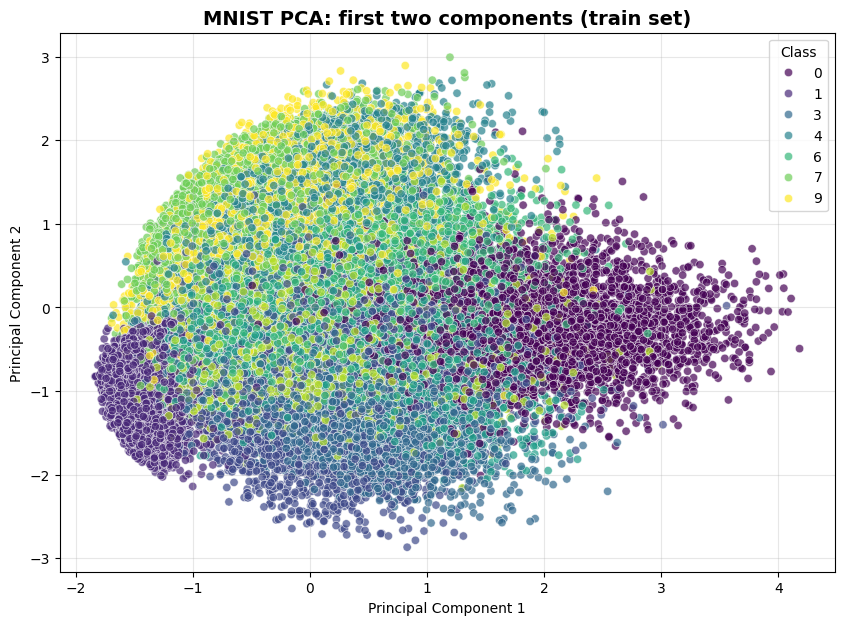

In [7]:
train_pca, _, _ = features['pca']
plt.figure(figsize=(10, 7))
sns.scatterplot(x=train_pca[:, 0], y=train_pca[:, 1], hue=y_train, palette='viridis', alpha=0.7)
plt.title('MNIST PCA: first two components (train set)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.legend(title='Class')
plt.show()

## 5) Hyperparameter Tuning (Cross-Validation) & Learning Curves

In [8]:
print('Hyperparameter tuning with cross-validation')

epsilons = [1e-6, 1e-4, 1e-3, 1e-2, 1e-1]
tuning_rows = []

for method in FEATURES:
    X_train_full, _, _ = features[method]
    best_eps, best_acc, detailed = run_simple_cv( X_train_full, y_train,
        NaiveBayes,
        epsilons,
        k=CV_FOLDS,
        return_details=True,
        verbose=False,
    )

    print(f"\n===== {method.upper()} features =====")
    table = pd.DataFrame(detailed)[['param', 'train_accuracy', 'val_accuracy']]
    table = table.rename(columns={
        'param': 'epsilon',
        'train_accuracy': 'train accuracy',
        'val_accuracy': 'val accuracy',
    })
    display(table)

    tuning_rows.append({
        'feature_method': method,
        'best_epsilon': float(best_eps),
        'best_val_accuracy': float(best_acc),
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values('best_val_accuracy', ascending=False).reset_index(drop=True)

print('\nBest tuning result per feature method:')
display(tuning_df)

best_method = tuning_df.loc[0, 'feature_method']
best_eps = float(tuning_df.loc[0, 'best_epsilon'])
print(f"\nSelected best configuration: feature={best_method}, epsilon={best_eps}")

Hyperparameter tuning with cross-validation

===== FLATTEN features =====


,epsilon,train accuracy,val accuracy
0,0.000001,0.435660,0.435556
1,0.000100,0.472545,0.472937
2,0.001000,0.506845,0.506964
3,0.010000,0.562197,0.562123
4,0.100000,0.624821,0.623889



===== HOG features =====


,epsilon,train accuracy,val accuracy
0,0.000001,0.704112,0.702440
1,0.000100,0.772059,0.770972
2,0.001000,0.805511,0.803968
3,0.010000,0.840813,0.839762
4,0.100000,0.866835,0.865992



===== PCA features =====


,epsilon,train accuracy,val accuracy
0,0.000001,0.856012,0.853294
1,0.000100,0.856022,0.853294
2,0.001000,0.856071,0.853353
3,0.010000,0.856687,0.853810
4,0.100000,0.853462,0.850595



Best tuning result per feature method:


,feature_method,best_epsilon,best_val_accuracy
0,hog,0.10,0.865992
1,pca,0.01,0.853810
2,flatten,0.10,0.623889



Selected best configuration: feature=hog, epsilon=0.1


### 5.2 Regularization (epsilon) and Bias–Variance Analysis

In [9]:
# Regularization / complexity analysis: epsilon effect on train vs validation

diag_val_size = min(1000, len(y_test))
reg_rows = []

for method in FEATURES:
    X_train_full, _, X_test_full = features[method]
    X_val_eval = X_test_full[:diag_val_size]
    y_val_eval = y_test[:diag_val_size]
    param_grid = [{'epsilon': e} for e in epsilons]

    df = complexity_curve(
        NaiveBayes,
        param_grid,
        X_train_full,
        y_train,
        X_val_eval,
        y_val_eval,
        model_name=f'NaiveBayes({method})',
    )
    df['feature_method'] = method
    reg_rows.append(df)

reg_df = pd.concat(reg_rows, ignore_index=True)
print('Regularization / bias-variance results:')
display(reg_df[['feature_method', 'epsilon', 'train_score', 'val_score', 'gap']])

Regularization / bias-variance results:


,feature_method,epsilon,train_score,val_score,gap
0,flatten,0.000001,0.435794,0.446,-0.010206
1,flatten,0.000100,0.470040,0.482,-0.011960
2,flatten,0.001000,0.502679,0.517,-0.014321
3,flatten,0.010000,0.556171,0.581,-0.024829
4,flatten,0.100000,0.620357,0.644,-0.023643
5,hog,0.000001,0.711171,0.732,-0.020829
6,hog,0.000100,0.776548,0.791,-0.014452
7,hog,0.001000,0.807837,0.815,-0.007163
8,hog,0.010000,0.840615,0.844,-0.003385
9,hog,0.100000,0.866250,0.874,-0.007750


### 5.3 Overfitting / Underfitting Diagnosis and Learning Curves

Learning-curve summary:


,train_size_requested,train_size,train_score,val_score,gap,diagnosis
0,0.10,5040,0.865278,0.870,-0.004722,high_bias
1,0.25,12600,0.864841,0.877,-0.012159,high_bias
2,0.50,25200,0.863571,0.864,-0.000429,high_bias
3,0.75,37800,0.863704,0.870,-0.006296,high_bias
4,1.00,50400,0.866250,0.874,-0.007750,high_bias


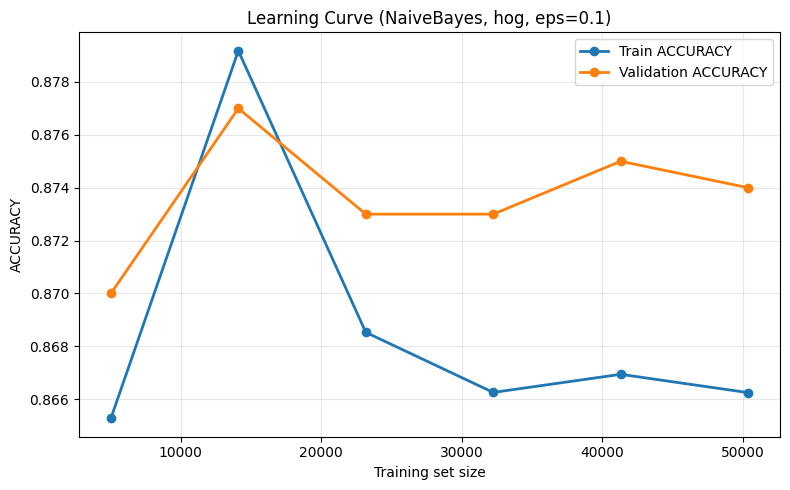

Learning-curve diagnosis:
  label: well-balanced
  gap:   -0.0078
  train: 0.8662
  val:   0.8740
  note:  Training and validation curves are reasonably close, so the model appears to generalize acceptably.


In [10]:
# Learning-curve analysis and overfitting / underfitting diagnosis

diag_val_size = min(1000, len(y_test))
train_best, _, test_best = features[best_method]
diag_x_val = test_best[:diag_val_size]
diag_y_val = y_test[:diag_val_size]

curve_df = learning_curve(
    lambda: NaiveBayes(epsilon=best_eps),
    train_best,
    y_train,
    diag_x_val,
    diag_y_val,
    train_sizes=(0.1, 0.25, 0.5, 0.75, 1.0),
    seeds=(RANDOM_STATE,),
    stratified=True,
    model_name=f'NaiveBayes({best_method})',
)
summary = summarize_bias_variance(curve_df)

print('Learning-curve summary:')
display(summary[['train_size_requested', 'train_size', 'train_score', 'val_score', 'gap', 'diagnosis']])

diag_curve = build_learning_curve(
    lambda: NaiveBayes(epsilon=best_eps),
    train_best,
    y_train,
    diag_x_val,
    diag_y_val,
    train_sizes=np.linspace(0.1, 1.0, 6),
    random_state=RANDOM_STATE,
)
plot_learning_curve(
    diag_curve,
    metric='accuracy',
    title=f'Learning Curve (NaiveBayes, {best_method}, eps={best_eps})',
)
plt.show()
print_diagnosis(diag_curve)

Learning-curve summary:


,train_size_requested,train_size,train_score,val_score,gap,diagnosis
0,0.10,5040,0.865278,0.870,-0.004722,high_bias
1,0.25,12600,0.864841,0.877,-0.012159,high_bias
2,0.50,25200,0.863571,0.864,-0.000429,high_bias
3,0.75,37800,0.863704,0.870,-0.006296,high_bias
4,1.00,50400,0.866250,0.874,-0.007750,high_bias


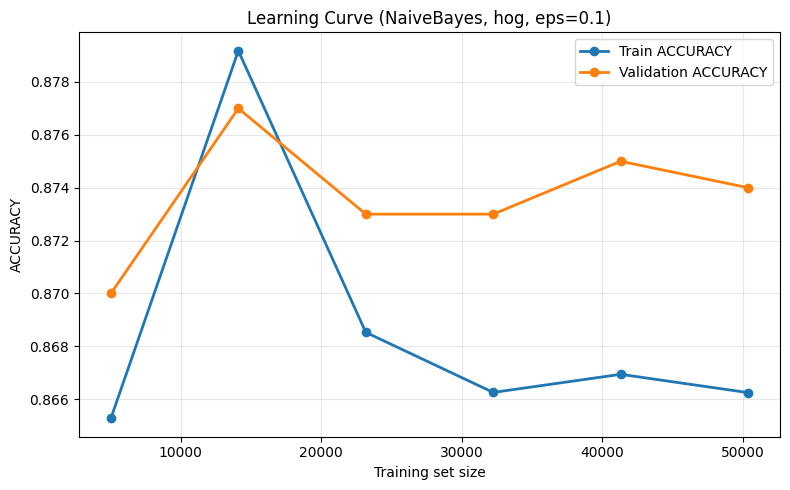

Learning-curve diagnosis:
  label: well-balanced
  gap:   -0.0078
  train: 0.8662
  val:   0.8740
  note:  Training and validation curves are reasonably close, so the model appears to generalize acceptably.


In [11]:
# Learning-curve analysis and overfitting / underfitting diagnosis

train_best, _, test_best = features[best_method]
diag_x_val = test_best[:diag_val_size]
diag_y_val = y_test[:diag_val_size]

curve_df = learning_curve(
    lambda: NaiveBayes(epsilon=best_eps),
    train_best,
    y_train,
    diag_x_val,
    diag_y_val,
    train_sizes=(0.1, 0.25, 0.5, 0.75, 1.0),
    seeds=(RANDOM_STATE,),
    stratified=True,
    model_name=f'NaiveBayes({best_method})',
)
summary = summarize_bias_variance(curve_df)

print('Learning-curve summary:')
display(summary[['train_size_requested', 'train_size', 'train_score', 'val_score', 'gap', 'diagnosis']])

diag_curve = build_learning_curve(
    lambda: NaiveBayes(epsilon=best_eps),
    train_best,
    y_train,
    diag_x_val,
    diag_y_val,
    train_sizes=np.linspace(0.1, 1.0, 6),
    random_state=RANDOM_STATE,
)
plot_learning_curve(
    diag_curve,
    metric='accuracy',
    title=f'Learning Curve (NaiveBayes, {best_method}, eps={best_eps})',
)
plt.show()
print_diagnosis(diag_curve)

## 6) Final Evaluation of Naive Bayes Model

In [12]:
# Final evaluation with the best tuned Naive Bayes setup
train_f, _, test_f = features[best_method]

# Use the full test set
test_eval_f = test_f
x_test_eval = x_test
y_test_eval = y_test

print(f"\n--- Training Naive Bayes (feature={best_method}, epsilon={best_eps}) ---")
final_model = NaiveBayes(epsilon=best_eps)
final_model.fit(train_f, y_train)

y_pred = final_model.predict(test_eval_f)

std_results = {
    'feature_method': best_method,
    'epsilon': best_eps,
    'accuracy': accuracy_score(y_test_eval, y_pred),
    'precision': precision_score(y_test_eval, y_pred, average='macro'),
    'recall': recall_score(y_test_eval, y_pred, average='macro'),
    'f1_score': f1_score(y_test_eval, y_pred, average='macro'),
    'confusion_matrix': confusion_matrix(y_test_eval, y_pred),
    'per_class_accuracy': per_class_accuracy(y_test_eval, y_pred),
    'test_preds': y_pred,
    'y_test_eval': y_test_eval,
    'x_test_eval': x_test_eval,
}

print(f"Eval samples: {len(y_test_eval)}")
print(f"Test Accuracy:  {std_results['accuracy']:.4f}")
print(f"Test Precision: {std_results['precision']:.4f}")
print(f"Test Recall:    {std_results['recall']:.4f}")
print(f"Test F1 Score:  {std_results['f1_score']:.4f}")


--- Training Naive Bayes (feature=hog, epsilon=0.1) ---
Eval samples: 14000
Test Accuracy:  0.8653
Test Precision: 0.8855
Test Recall:    0.8637
Test F1 Score:  0.8663


### 6.1 Misclassified Examples (Best Model)

Best overall: HOG with epsilon=0.1
Total misclassified: 1886 out of 14000


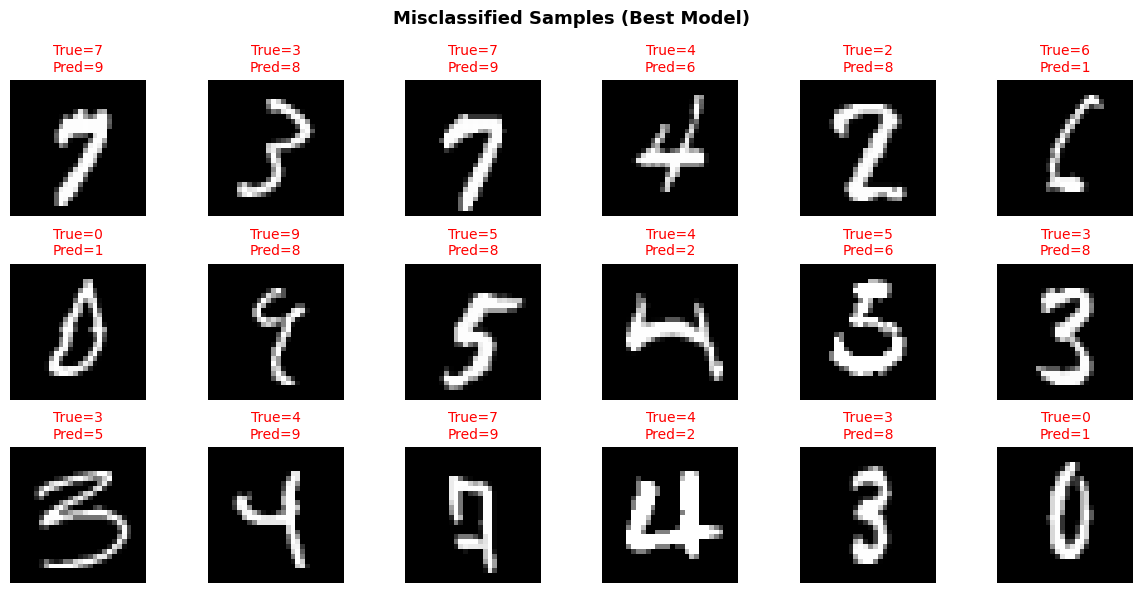

In [13]:
# Misclassified examples for the best model on the full test set
best_method = std_results['feature_method']
best_eps_final = std_results['epsilon']
print(f'Best overall: {best_method.upper()} with epsilon={best_eps_final}')

x_eval = std_results['x_test_eval']
y_eval = std_results['y_test_eval']
y_pred_best = std_results['test_preds']

misclassified = np.where(y_pred_best != y_eval)[0]
print(f'Total misclassified: {len(misclassified)} out of {len(y_eval)}')

n_show = min(18, len(misclassified))
if n_show > 0:
    n_cols = 6
    n_rows = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2 * n_rows))
    axes = np.asarray(axes).reshape(-1)

    for i, idx in enumerate(misclassified[:n_show]):
        axes[i].imshow(x_eval[idx], cmap='gray')
        axes[i].set_title(f'True={y_eval[idx]}\nPred={y_pred_best[idx]}', fontsize=10, color='red')
        axes[i].axis('off')

    for i in range(n_show, len(axes)):
        axes[i].axis('off')

    fig.suptitle('Misclassified Samples (Best Model)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No misclassified samples!')

### 6.2 Per-Class Accuracy (Recall) for the Best Model

In [14]:
# Per-class recall (all digits 0..9)
pca = std_results['per_class_accuracy']

print('Per-class Recall:')
for label in range(10):
    print(f'  Digit {label}: {pca.get(label, 0.0)*100:.2f}%')

Per-class Recall:
  Digit 0: 96.72%
  Digit 1: 98.19%
  Digit 2: 82.10%
  Digit 3: 76.34%
  Digit 4: 76.22%
  Digit 5: 80.68%
  Digit 6: 94.70%
  Digit 7: 74.85%
  Digit 8: 88.50%
  Digit 9: 95.42%


### 6.3 Confusion Matrix (10x10)

Confusion Matrix - Best Tuned Naive Bayes


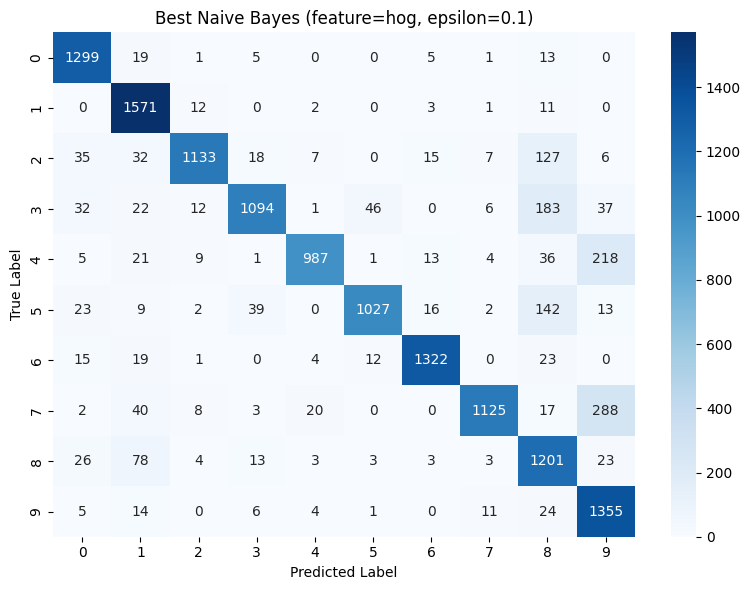

Accuracy: 0.8653
Macro F1: 0.8663


In [15]:
print('Confusion Matrix - Best Tuned Naive Bayes')
fig, ax = plt.subplots(figsize=(8, 6))

cm = std_results['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax)
ax.set_title(f"Best Naive Bayes (feature={std_results['feature_method']}, epsilon={std_results['epsilon']})")
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

print(f"Accuracy: {std_results['accuracy']:.4f}")
print(f"Macro F1: {std_results['f1_score']:.4f}")